# Addition accuracy versus filler length — 5-shot tests

Separate exact-answer accuracy plots for five-shot DeepSeek V4 Flash evaluations:

- **One-fact addition:** 262 facts per condition, at k = 0, 5, 10, 20, 50, 100. The k=5 supplement was evaluated on September 12, 2026; the other conditions retain the September 3 results. The derived view is `one-fact-addition-5shot-with-k5`.
- **Two-fact addition:** the unchanged September 3 `two-fact-addition-5shot-cyclic` evaluation, with 260 mixed-fact cyclic pairs at k = 0, 10, 20, 50, 100.

Each condition uses five fixed demonstrations, greedy decoding, and the same number of dots before `Answer:` in every demonstration and target. The k=5 supplement retains the original facts and addends. It uses a new runtime; the pointwise intervals below do not estimate variation between runtimes. The later atomic-only two-fact experiment is a separate dataset.


In [7]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path('/pscratch/sd/m/marocco/sandbox/mech_int')
sys.path.insert(0, str(PROJECT_ROOT))

from filler.addition.accuracy_plot import plot_addition_accuracy

FIVE_SHOT_SUMMARIES = {
    'One-fact addition': Path('runs/deepseek-v4-flash/one-fact-addition-5shot-full/summary.json'),
    'Two-fact addition': Path('runs/deepseek-v4-flash/two-fact-addition-5shot-cyclic/summary.json'),
}

# Prefer the derived six-length view when its k=5 supplement is complete.
combined = Path('runs/deepseek-v4-flash/one-fact-addition-5shot-with-k5/summary.json')
if (PROJECT_ROOT / combined).is_file():
    FIVE_SHOT_SUMMARIES['One-fact addition'] = combined
    print('k=5 uses a new runtime; the other one-fact lengths are historical.')

# Verify the saved protocol and full condition coverage before plotting.
for task, relative_path in FIVE_SHOT_SUMMARIES.items():
    run_dir = PROJECT_ROOT / relative_path.parent
    config = json.loads((run_dir / 'run_config.json').read_text())
    summary = json.loads((run_dir / 'summary.json').read_text())
    assert config['mode'] == 'generation', task
    assert len(config['demonstrations']) == 5, task
    expected_count = config['source'].get('selected_facts', config['source'].get('selected_pairs'))
    expected_conditions = {'baseline' if k == 0 else f'dots_{k}' for k in config['filler_lengths']}
    assert set(summary['conditions']) == expected_conditions, task
    assert all(point['count'] == expected_count for point in summary['conditions'].values()), task
    assert summary['result_count'] == expected_count * len(expected_conditions), task
    print(f"{task}: {expected_count} items per condition; run created {config['created_at_utc']}")


k=5 uses a new runtime; the other one-fact lengths are historical.
One-fact addition: 262 items per condition; run created 2026-09-12T01:30:50.517337+00:00
Two-fact addition: 260 items per condition; run created 2026-09-03T22:05:10.974597+00:00


## Error-bar formula

For each condition, let $k$ be the number of correct answers, $n$ the number of evaluated items, and $\hat p=k/n$ the plotted accuracy. The error bars are **two-sided 95% Wilson binomial confidence intervals**, with $z=1.959963984540054$:

$$
L,U = \frac{\hat p + \frac{z^2}{2n} \;\mp\; z\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}}{1+\frac{z^2}{n}}.
$$

The lower and upper error-bar lengths passed to Matplotlib are $\hat p-L$ and $U-\hat p$, respectively. They are generally asymmetric. The implementation is `wilson_interval` in `filler/addition/accuracy_plot.py`.

Here $n=262$ for one-fact addition and $n=260$ for two-fact addition, separately at each filler length. These are pointwise intervals under an independent Bernoulli-item model. Cyclic two-fact pairs share source facts, so their intervals do not account for dependence from fact reuse. Conditions also reuse the same items: these bars do not measure uncertainty in paired changes from baseline or variability across model reruns.


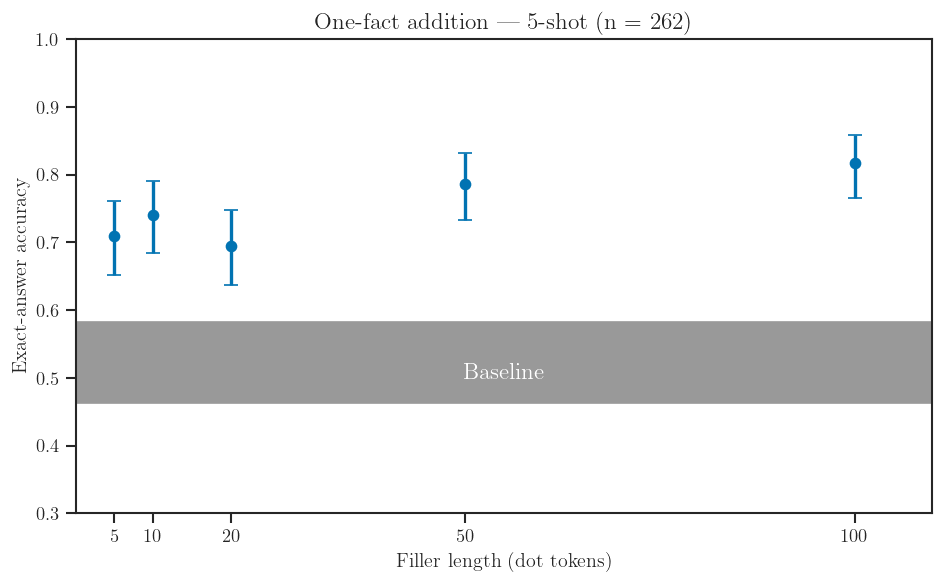

In [8]:
one_fact_fig, one_fact_ax, one_fact_data = plot_addition_accuracy(
    PROJECT_ROOT, summaries={'One-fact addition': FIVE_SHOT_SUMMARIES['One-fact addition']},
    connect_points=False, baseline_band=True,
)
one_fact_ax.set_title('One-fact addition — 5-shot (n = 262)')
one_fact_fig.tight_layout()
display(one_fact_fig)

one_fact_fig.savefig(PROJECT_ROOT / 'notebooks/one_fact_eval.png', dpi=600, bbox_inches='tight')
plt.close(one_fact_fig)


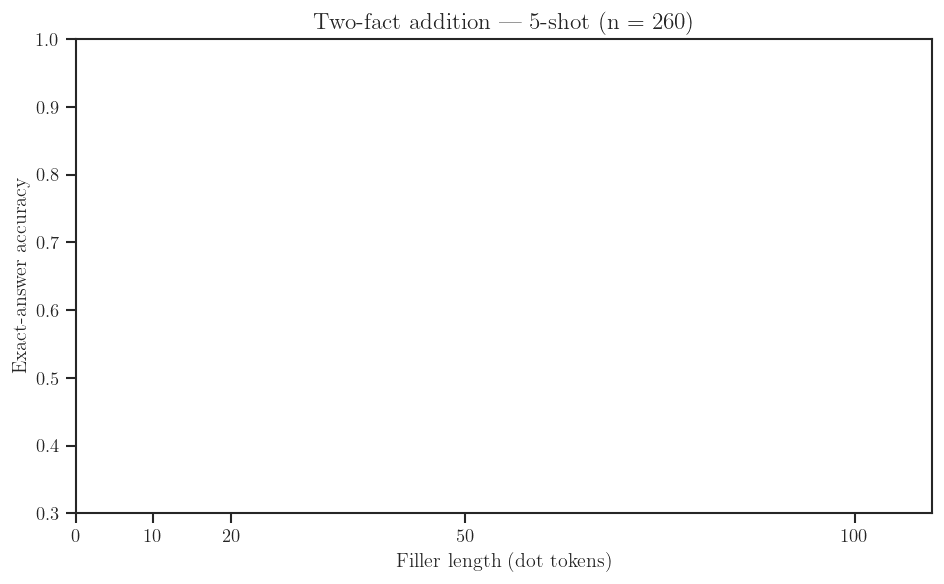

In [9]:
two_fact_fig, two_fact_ax, two_fact_data = plot_addition_accuracy(
    PROJECT_ROOT, summaries={'Two-fact addition': FIVE_SHOT_SUMMARIES['Two-fact addition']}
)
two_fact_ax.set_title('Two-fact addition — 5-shot (n = 260)')
two_fact_fig.tight_layout()
display(two_fact_fig)
plt.close(two_fact_fig)


In [10]:
# Inspect the exact counts, accuracy, and Wilson interval endpoints.
plotted_data = {**one_fact_data, **two_fact_data}
for task, points in plotted_data.items():
    print(task)
    print(' dots  correct/total   accuracy       95% Wilson CI')
    for point in points:
        print(f"{point['filler_length']:5d}  {point['correct']:3d}/{point['count']:<3d}"
              f"          {point['accuracy']:.2%}      "
              f"[{point['ci_low']:.2%}, {point['ci_high']:.2%}]")


One-fact addition
 dots  correct/total   accuracy       95% Wilson CI
    0  137/262          52.29%      [46.25%, 58.26%]
    5  186/262          70.99%      [65.23%, 76.15%]
   10  194/262          74.05%      [68.42%, 78.98%]
   20  182/262          69.47%      [63.64%, 74.73%]
   50  206/262          78.63%      [73.27%, 83.16%]
  100  214/262          81.68%      [76.55%, 85.89%]
Two-fact addition
 dots  correct/total   accuracy       95% Wilson CI
    0   20/260          7.69%      [5.03%, 11.58%]
   10   13/260          5.00%      [2.94%, 8.37%]
   20   17/260          6.54%      [4.12%, 10.22%]
   50   15/260          5.77%      [3.53%, 9.30%]
  100   17/260          6.54%      [4.12%, 10.22%]


In [11]:
# Export each plot as a standalone artifact.
output_dir = PROJECT_ROOT / 'runs/deepseek-v4-flash/plots'
output_dir.mkdir(parents=True, exist_ok=True)
for name, figure in [('one-fact', one_fact_fig), ('two-fact', two_fact_fig)]:
    stem = f'{name}-addition-5shot-accuracy-vs-filler'
    figure.savefig(output_dir / f'{stem}.pdf', bbox_inches='tight')
    figure.savefig(output_dir / f'{stem}.png', dpi=200, bbox_inches='tight')


## Five-shot repeat patching

This separate campaign uses all 262 saved five-shot examples, with fresh k=0 and k=20 reference runs. For source filler indices 0–6, its clean post-block mHC residual is copied into every later filler in the final question, at layers 0–42 on all four ranks. Demonstration tokens are preserved. The x-axis counts untouched fillers: x=1 replaces 19 fillers; x=6 replaces 14; x=7 replaces 13.

Accuracy uses strict integer parsing of the complete greedy response (at most eight new tokens), including examples with incorrect clean answers. Points and the two full-width reference bands use pointwise 95% Wilson intervals. These intervals do not measure uncertainty in paired differences or variation between runtimes. The original six interventions and fresh references are saved in complete example blocks. The additional x=7 point uses separate identity/intervention blocks with the exact same warm runtime and saved clean k=20 donors and references; it appears after all 262 extension examples pass their audit. The earlier evaluation plots remain historical.

The overwrite constrains residual states between blocks; it does not remove filler positions or undo attention/KV computations already performed within a block.

Set `REPEAT_ALLOW_PARTIAL = True` below to preview complete checkpoint blocks during the run. Each preview uses the same completed-example subset for every point and both fresh references, and compares historical accuracy on that subset. The title reports the included count. Preview intervals do not correct for inspecting results repeatedly or for the ordered subset. Final all-capture reconciliation remains pending until campaign completion.


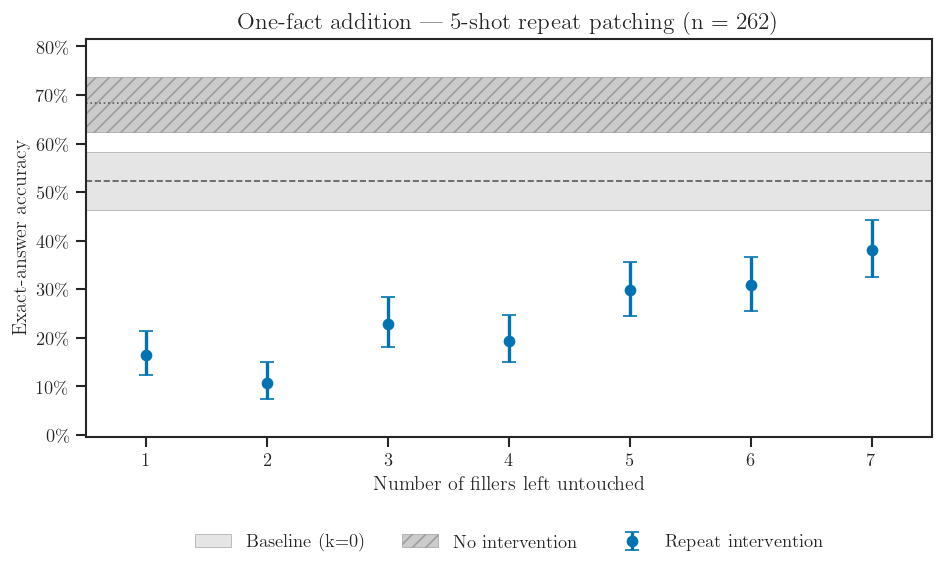

Fresh results (exact counts and 95% Wilson intervals):
baseline: 137/262 = 52.29%; [46.25%, 58.26%]
no_intervention: 179/262 = 68.32%; [62.46%, 73.65%]
1 fillers untouched: 43/262 = 16.41%; [12.42%, 21.38%]
2 fillers untouched: 28/262 = 10.69%; [7.50%, 15.01%]
3 fillers untouched: 60/262 = 22.90%; [18.23%, 28.36%]
4 fillers untouched: 51/262 = 19.47%; [15.13%, 24.69%]
5 fillers untouched: 78/262 = 29.77%; [24.56%, 35.57%]
6 fillers untouched: 81/262 = 30.92%; [25.63%, 36.75%]
7 fillers untouched: 100/262 = 38.17%; [32.50%, 44.18%]
Historical references for these same included examples:
k=0: 137/262 = 52.29%
k=20: 182/262 = 69.47%


In [3]:
from filler.dsv4.five_shot_repeat_plot import plot_five_shot_repeat

REPEAT_ALLOW_PARTIAL = True
repeat_root = PROJECT_ROOT / 'runs/deepseek-v4-flash/one-fact-patching-five-shot-repeat'
if not (repeat_root / 'COMPLETE.json').is_file() and not REPEAT_ALLOW_PARTIAL:
    print('Five-shot repeat campaign pending: fresh accuracies are not available yet.')
else:
    repeat_fig, repeat_ax, repeat_report = plot_five_shot_repeat(repeat_root, allow_partial=REPEAT_ALLOW_PARTIAL)
    preliminary = repeat_report.get('preliminary', False)
    if preliminary:
        print(f"PRELIMINARY: {repeat_report['completed_examples']}/262 complete examples; final integrity audit pending.")
    display(repeat_fig)
    export_dir = repeat_root / ('preview' if preliminary else 'analysis')
    export_dir.mkdir(parents=True, exist_ok=True)
    export_stem = 'five-shot-repeat-preview' if preliminary else 'five-shot-repeat-accuracy'
    (export_dir / 'plotted_report.json').write_text(json.dumps(repeat_report, indent=2))
    (export_dir / 'plotted_counts.json').write_text(json.dumps(repeat_report['points'], indent=2))
    for suffix in ('png', 'pdf'):
        repeat_fig.savefig(export_dir / f'{export_stem}.{suffix}',
                           dpi=200, bbox_inches='tight')
    plt.close(repeat_fig)
    print('Fresh results (exact counts and 95% Wilson intervals):')
    for p in repeat_report['points']:
        label = p['condition'] if p['untouched'] is None else f"{p['untouched']} fillers untouched"
        print(f"{label}: {p['correct']}/{p['count']} = {p['accuracy']:.2%}; "
              f"[{p['ci_low']:.2%}, {p['ci_high']:.2%}]")
    print('Historical references for these same included examples:')
    for k, p in repeat_report['historical'].items():
        print(f"k={k}: {p['correct']}/{p['count']} = {p['correct']/p['count']:.2%}")


## Random versus copy interventions — 96 discovery prompts

This comparison uses the same **96 discovery prompts** for both policies, including clean errors. It is a separate dataset and scoring protocol from the 262-example five-shot experiment above: accuracy here is canonical single-token greedy answer accuracy.

At cutoff $j=0,\ldots,5$, fillers $0,\ldots,j$ remain untouched and fillers $j+1,\ldots,19$ are replaced at every post-block layer 0–42. The x-axis shows **$j+1$ untouched fillers**. Random replacement uses independent directions for each prompt, layer, and filler, preserving each destination's clean full-residual norm. Copy replacement repeats clean filler $j$, including its source norm, at every later filler. Both recompute the full prompt.

Points and the clean reference band use the saved **95% whole-panel bootstrap intervals** (2,000 shared resamples of 24 four-prompt panels, seed 42), rather than the Wilson intervals above. Each policy retains its own runtime baseline; all clean predictions agree (83/96 correct). Uncertainty is conditional on one noise realization (seed 42), and does not estimate between-runtime variation. Moving along the x-axis also changes the number of replacements. The policies differ in both direction and norm treatment.

Source: [`one-fact-patching-filler-random/comparison/REPORT.md`](../runs/deepseek-v4-flash/one-fact-patching-filler-random/comparison/REPORT.md), with independently audited per-example exports and bootstrap statistics.


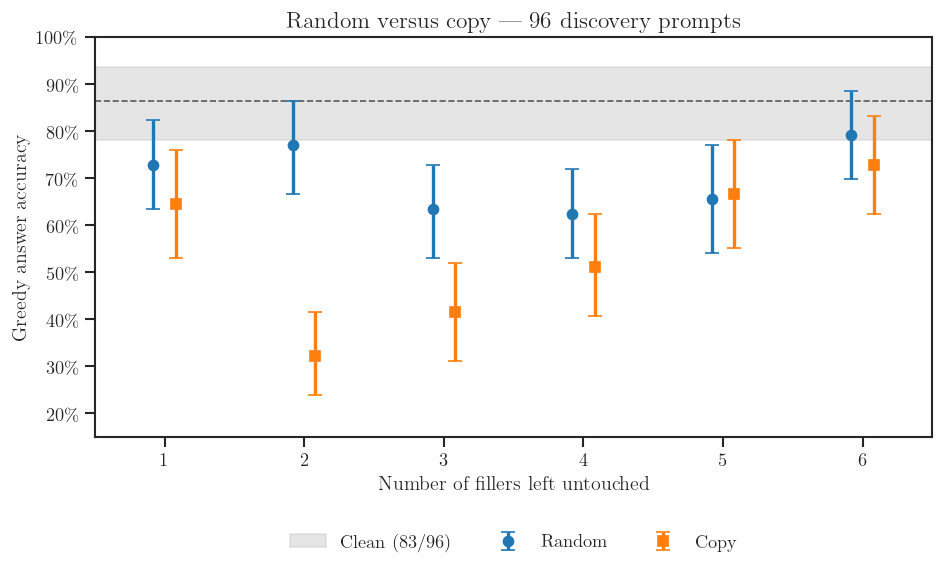

Untouched   Random   Copy   (correct / 96)
        1       70     62
        2       74     31
        3       61     40
        4       60     49
        5       63     64
        6       76     70
95% panel-bootstrap intervals; conditional on one noise realization.


In [2]:
import csv
from matplotlib.ticker import PercentFormatter

random_root = PROJECT_ROOT / 'runs/deepseek-v4-flash/one-fact-patching-filler-random'
random_comparison = json.loads((random_root / 'comparison/summary.json').read_text())
random_complete = json.loads((random_root / 'COMPLETE.json').read_text())
random_audit = json.loads((random_root / 'comparison/export-validation.json').read_text())
assert random_complete['status'] == 'complete' and random_complete['integrity']['passed']
assert random_comparison['config_hash'] == random_complete['config_hash']
assert random_audit['passed'] and random_audit['examples'] == 1152
assert random_comparison['resamples'] == 2000 and random_comparison['seed'] == 42

# Reconcile plotted counts with the per-example export, retaining clean errors.
with (random_root / 'comparison/per_example.csv').open() as handle:
    random_rows = list(csv.DictReader(handle))
random_counts = {p['site']: p for p in random_comparison['accuracy_counts']}
random_estimates = {(p['site'], p['metric']): p for p in random_comparison['conditions']}
expected_sites = {f'{prefix}{j}' for prefix in ('random_after_', 'repeat_filler_') for j in range(6)}
assert set(random_counts) == {r['site'] for r in random_rows} == expected_sites
reference_clean = None
for site, point in random_counts.items():
    rows = [r for r in random_rows if r['site'] == site]
    clean = {r['target_id']: int(r['clean_correct']) for r in rows}
    assert len(rows) == len(clean) == point['n'] == 96
    assert sum(clean.values()) == point['clean_correct'] == 83
    assert sum(int(r['patched_correct']) for r in rows) == point['patched_correct']
    assert abs(random_estimates[site, 'patched_accuracy_pct']['mean'] - 100*point['patched_correct']/96) < 1e-10
    if reference_clean is None:
        reference_clean = clean
    assert clean == reference_clean

# Keep the caller's font and TeX settings; use the existing marker-only style.
random_fig, random_ax = plt.subplots(figsize=(8, 5))
clean_estimate = random_estimates['random_after_0', 'clean_accuracy_pct']
assert all(random_estimates[site, 'clean_accuracy_pct'] ==
           {**clean_estimate, 'site': site} for site in expected_sites)
random_ax.axhspan(clean_estimate['ci_low']/100, clean_estimate['ci_high']/100,
                  color='0.78', alpha=.45, label='Clean (83/96)', zorder=0)
random_ax.axhline(clean_estimate['mean']/100, color='0.35', linestyle='--', linewidth=1)
for prefix, label, color, marker, offset in (
        ('random_after_', 'Random', 'tab:blue', 'o', -.08),
        ('repeat_filler_', 'Copy', 'tab:orange', 's', .08)):
    estimates = [random_estimates[f'{prefix}{j}', 'patched_accuracy_pct'] for j in range(6)]
    random_ax.errorbar([j+1+offset for j in range(6)], [p['mean']/100 for p in estimates],
        yerr=[[(p['mean']-p['ci_low'])/100 for p in estimates],
              [(p['ci_high']-p['mean'])/100 for p in estimates]],
        marker=marker, color=color, linestyle='none', capsize=4, linewidth=2, label=label)
random_ax.set(xlabel='Number of fillers left untouched', ylabel='Greedy answer accuracy',
              title='Random versus copy — 96 discovery prompts',
              xticks=range(1, 7), xlim=(.5, 6.5), ylim=(.15, 1))
random_ax.yaxis.set_major_formatter(PercentFormatter(1))
random_ax.legend(loc='upper center', bbox_to_anchor=(.5, -.2), ncol=3, frameon=False, fontsize=11)
random_fig.tight_layout()
display(random_fig)
random_output = PROJECT_ROOT / 'notebooks/plots'
random_output.mkdir(parents=True, exist_ok=True)
for suffix in ('png', 'pdf'):
    random_fig.savefig(random_output / f'filler-random-vs-copy-accuracy.{suffix}',
                       dpi=200, bbox_inches='tight')
plt.close(random_fig)
print('Untouched   Random   Copy   (correct / 96)')
for j in range(6):
    print(f"{j+1:9d}   {random_counts[f'random_after_{j}']['patched_correct']:6d}"
          f"   {random_counts[f'repeat_filler_{j}']['patched_correct']:4d}")
print('95% panel-bootstrap intervals; conditional on one noise realization.')
